In [18]:
import os
# ---- cell 1: imports & paths
from pathlib import Path
import json, math, csv
from collections import defaultdict
import numpy as np
import networkx as nx
from PyQt6.sip import assign
from scipy.sparse import coo_matrix, save_npz
import matplotlib.pyplot as plt
from collections import defaultdict

# repo gốc: Urban-Traffic-Links (2 cấp trên file hiện tại)
PROJECT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path.cwd().parents[2]
print(PROJECT)
RAW = PROJECT / "data" / "raw" / "tomtom_stats"
INPUT_JSON = RAW / "7987791_HCMC_D1_Weekday_15min_unzipped.json"

GRAPH_DIR = PROJECT / "data" / "processed" / "tomtom_stats" / "graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

VIZ_DIR = PROJECT / "data" / "visualization"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print(INPUT_JSON.exists(), INPUT_JSON)


C:\AI\Specialized_Project2_github\Urban-Traffic-Links
True C:\AI\Specialized_Project2_github\Urban-Traffic-Links\data\raw\tomtom_stats\7987791_HCMC_D1_Weekday_15min_unzipped.json


In [19]:
def haversine_m(lat1,lon1,lat2,lon2):
    R = 6371000
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    deltaphi = phi2 - phi1
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dlambda/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2*R*math.asin(math.sqrt(a))

def cell_key(lat,lon, meters=10):
    dlat = meters / 111320.0
    dlon = meters / (111320.0 * max(0.2, math.cos(math.radians(lat))))
    return (int(lat/dlat), int(lon/dlon))


In [20]:
with open(INPUT_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)
segments = data['network']['segmentResults']
seg_endpoints={}
for seg in segments:
    sid = seg["segmentId"]
    shp = seg.get("shape") or []
    if len(shp) >= 2:
        a = shp[0]
        b = shp[-1]
        seg_endpoints[sid] = [(a["latitude"],a["longitude"]),(b["latitude"],b["longitude"])]
len(seg_endpoints)

6309

In [21]:
THERSHOLD_METERS = 10.0
grid = defaultdict(list)
nodes = {}
node_of_endpoint = {}
next_node_id = 0
for sid, ends in seg_endpoints.items():
    for(ei, (lat,lon)) in enumerate(ends):
        ck = cell_key(lat,lon,meters=THERSHOLD_METERS)
        cand = []
        #ck[0] rơi vào ô , ck[1] rơi vào cột
        for di in [-1,0,1]:
            for dj in [-1,0,1]:
                cand.extend(grid.get((ck[0]+di,ck[1]+dj),[]))
        assigned = None
        for nid, nlat, nlon in cand:
            if haversine_m(lat,lon,nlat,nlon) <= THERSHOLD_METERS:
                assigned = nid
                break
        if assigned is None:
            nid = next_node_id
            next_node_id += 1
            nodes[nid] = lat,lon
            grid[ck].append((nid, lat, lon))
            assigned = nid
        node_of_endpoint[(sid, ei)] = assigned
len(nodes)

2703

Build Graph Structures

In [22]:
#seg_to_nodes cho biết sid nối node nào với node nào
#otherwise node_to_segs liệt kê tất cả segment đi qua node nid
seg_to_nodes = {}
node_to_segs = defaultdict(list)
for sid in seg_endpoints.keys():
    u = node_of_endpoint[(sid,0)]
    v = node_of_endpoint[(sid,1)]
    if u != v:
        seg_to_nodes[sid]=(u,v)
        node_to_segs[u].append(sid)
        node_to_segs[v].append(sid)
seg_edges = set()
for nid, segs_here in node_to_segs.items():
    sh = list(segs_here)
    for i in range(len(sh)):
        for j in range(i+1,len(sh)):
            a,b = sh[i],sh[j]
            seg_edges.add(tuple(sorted((a, b))))
len(seg_edges), len(seg_to_nodes)



(20507, 5713)

Save CSV nodes/segments/adjacency edges

In [23]:
#nodes.csv
with open(GRAPH_DIR / "node.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["node_id","lat","lon","segments_count"])
    for nid,(lat,lon) in nodes.items():
        w.writerow([nid, f"{lat:.7f}", f"{lon:.7f}", len(node_to_segs.get(nid,[]))])

#segments.csv
props = {s["segmentId"]: s for s in segments}
with open(GRAPH_DIR / "segements.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["segment_id","node_u","node_v","streetName","frc","speedLimit","distance"])
    for sid, (u,v) in seg_to_nodes.items():
        p = props[sid]
        w.writerow([sid,u,v,p.get("streetName",""),p.get("frc",""),p.get("speedLimit",""), p.get("distance","")])

#edges.csv
with open(GRAPH_DIR / "edges.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["segment_u","segment_v"])
    for a,b in sorted(list(seg_edges)):
        w.writerow([a,b])



Build sparse adjacency matrix

In [24]:
seg_ids = sorted(seg_to_nodes.keys())
index = {sid:i for i,sid in enumerate(seg_ids)}
row,col = [],[]
for a,b in seg_edges:
    i,j = index[a], index[b]
    row += [i,j]
    col += [j,i]
data_ones = np.ones(len(row), dtype=np.uint8)
A = coo_matrix((data_ones, (row,col)), shape=(len(seg_ids), len(seg_ids)))
# lưu map chỉ số
with open(GRAPH_DIR / "segment_index.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f); w.writerow(["idx","segment_id"])
    for sid in seg_ids:
        w.writerow([index[sid], sid])

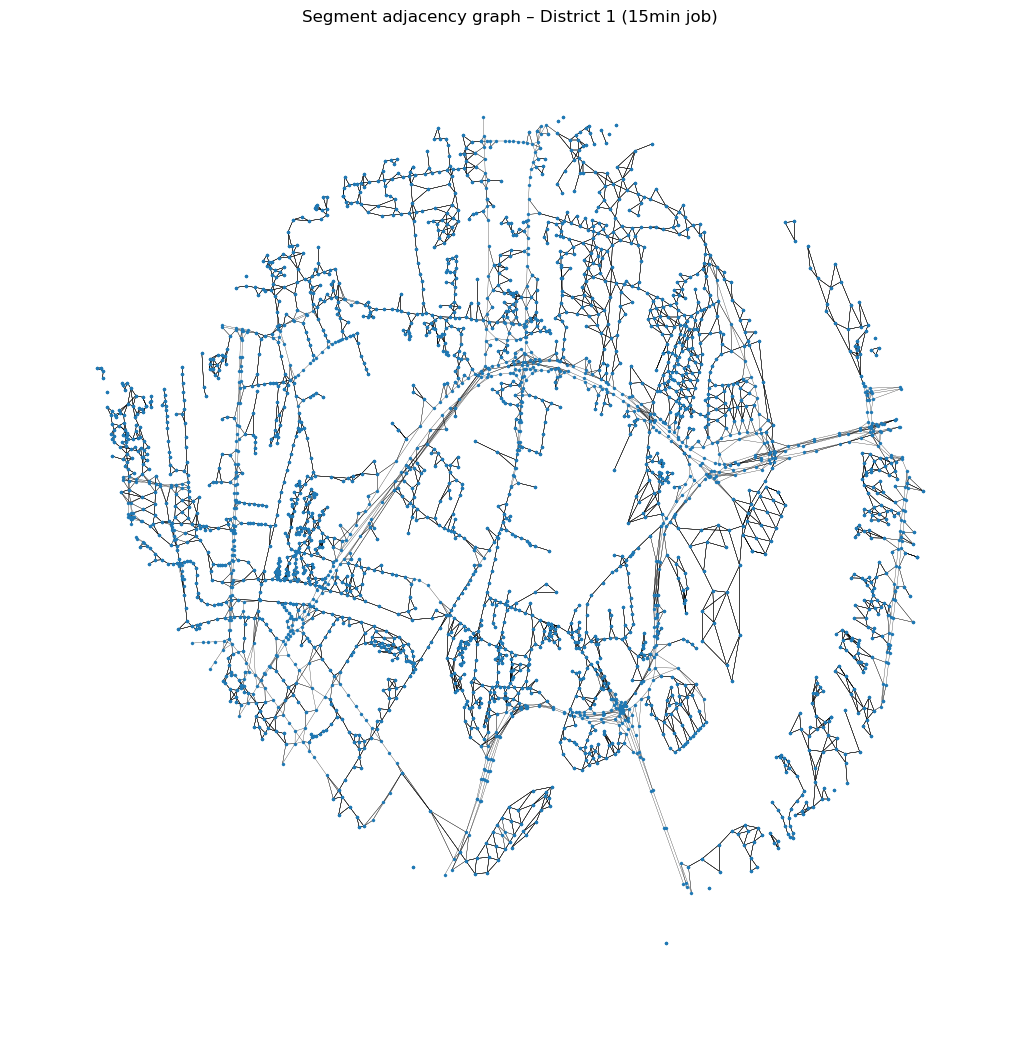

Saved: C:\AI\Specialized_Project2_github\Urban-Traffic-Links\data\visualization\graph_d1_segments.png


In [25]:
# quick plot (lon-x, lat-y), lưu ảnh PNG
G = nx.Graph()
for sid,(u,v) in seg_to_nodes.items():
    G.add_node(sid)
for a,b in seg_edges:
    G.add_edge(a,b)

# vị trí nút segment = trọng tâm 2 endpoint để vẽ
pos = {}
for sid,(u,v) in seg_to_nodes.items():
    lat1,lon1 = nodes[u]
    lat2,lon2 = nodes[v]
    pos[sid] = ((lon1+lon2)/2, (lat1+lat2)/2)

plt.figure(figsize=(10,10))
nx.draw(G, pos=pos, node_size=5, linewidths=0.2, width=0.2)
plt.title("Segment adjacency graph – District 1 (15min job)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
out_png = VIZ_DIR / "graph_d1_segments.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
